In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gregorut/videogamesales/vgsales.csv
/kaggle/input/datasets/pasquale95/vgsales/vgsales.csv


**Data Cleaning**

In [2]:
#load dataset

df = pd.read_csv("/kaggle/input/datasets/gregorut/videogamesales/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
df = df.drop_duplicates()

In [4]:
df.columns = df.columns.str.lower()

In [5]:
# Initial data exploration

df.dtypes

rank              int64
name             object
platform         object
year            float64
genre            object
publisher        object
na_sales        float64
eu_sales        float64
jp_sales        float64
other_sales     float64
global_sales    float64
dtype: object

In [6]:
df.isnull().sum()

rank              0
name              0
platform          0
year            271
genre             0
publisher        58
na_sales          0
eu_sales          0
jp_sales          0
other_sales       0
global_sales      0
dtype: int64

Rows with missing values for the column "Year" represents about 1.7% of the dataset. Since they are a negligible number and their presence hinders the analysis of the time series, the records without the release year will be eliminated.

In [7]:
df['year'].isna().mean()*100

np.float64(1.6327268345583803)

In [8]:
df = df.dropna(subset = 'year')
df['year'] = df['year'].astype(int)

For the missing values in the column Publisher I have first tried to fill them using a function that maps similar name in the dataset (i.e. it is likely that FIFA 13 has the same publisher of FIFA 14). The remaining null values has been filled with "Unknown" to keep the records for further analyses

In [9]:
df['publisher'].value_counts()

publisher
Electronic Arts                 1339
Activision                       966
Namco Bandai Games               928
Ubisoft                          918
Konami Digital Entertainment     823
                                ... 
King Records                       1
Graphsim Entertainment             1
Takuyo                             1
Inti Creates                       1
Commseed                           1
Name: count, Length: 576, dtype: int64

In [10]:
missing_publishers = df[df["publisher"].isna()]
missing_publishers.head()

,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
1662,1664,Shrek / Shrek 2 2-in-1 Gameboy Advance Video,GBA,2007,Misc,NaN,0.87,0.32,0.0,0.02,1.21
2222,2224,Bentley's Hackpack,GBA,2005,Misc,NaN,0.67,0.25,0.0,0.02,0.93
3159,3161,Nicktoons Collection: Game Boy Advance Video V...,GBA,2004,Misc,NaN,0.46,0.17,0.0,0.01,0.64
3166,3168,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004,Misc,NaN,0.46,0.17,0.0,0.01,0.64
3766,3768,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004,Misc,NaN,0.38,0.14,0.0,0.01,0.53


In [11]:
#Function to fill the column Publisher based on similar name values in the dataset

publisher_lookup = (df.dropna(subset=["publisher"]).groupby("name")["publisher"].agg(lambda x: x.mode()[0]))

df["publisher"] = df["publisher"].fillna(df["name"].map(publisher_lookup))

In [12]:
df['publisher'] = df.publisher.fillna("unknown")

In [13]:
df.to_csv('clean_vgsales.csv', index = False)

**Business Questions**



The objective of this analysis is to understand the video game market by answering the following questions:

1. Which games generated the highest global sales?
2. Which genres are the most successful?
3. Which platforms generated the highest sales?
4. How have global sales changed over time?

***which games generated the highest global sales?***

In [14]:
#build a dataset sorting by total sales and keeping the first 10 records

top_sales = (df.groupby("name").agg({'eu_sales': 'sum', 'na_sales': 'sum', 'jp_sales': 'sum', 'other_sales': 'sum','global_sales':'sum'}).sort_values(by='global_sales', ascending=False).head(10).reset_index())
top_sales

,name,eu_sales,na_sales,jp_sales,other_sales,global_sales
0,Wii Sports,29.02,41.49,3.77,8.46,82.74
1,Grand Theft Auto V,23.04,23.46,1.39,8.03,55.92
2,Super Mario Bros.,4.88,32.48,6.96,0.99,45.31
3,Tetris,2.95,26.17,6.03,0.69,35.84
4,Mario Kart Wii,12.88,15.85,3.79,3.31,35.82
5,Wii Sports Resort,11.01,15.75,3.28,2.96,33.00
6,Pokemon Red/Pokemon Blue,8.89,11.27,10.22,1.00,31.37
7,Call of Duty: Modern Warfare 3,11.29,15.58,0.62,3.35,30.83
8,New Super Mario Bros.,9.23,11.38,6.50,2.90,30.01
9,Call of Duty: Black Ops II,11.05,14.08,0.72,3.88,29.72


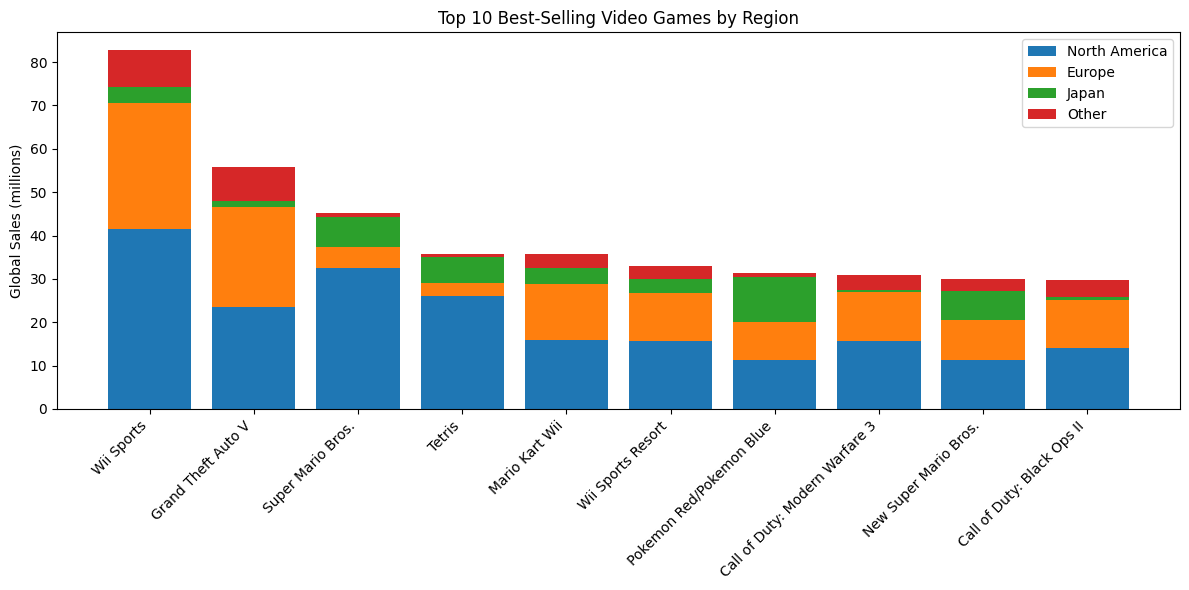

In [15]:
#bar chart with global sales divided by regional sales

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(top_sales["name"], top_sales["na_sales"], label="North America")

plt.bar(
    top_sales["name"],
    top_sales["eu_sales"],
    bottom=top_sales["na_sales"],
    label="Europe"
)

plt.bar(
    top_sales["name"],
    top_sales["jp_sales"],
    bottom=top_sales["na_sales"] + top_sales["eu_sales"],
    label="Japan"
)

plt.bar(
    top_sales["name"],
    top_sales["other_sales"],
    bottom=top_sales["na_sales"] + top_sales["eu_sales"] + top_sales["jp_sales"],
    label="Other"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Global Sales (millions)")
plt.title("Top 10 Best-Selling Video Games by Region")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
sales_summary = (df[["na_sales", "eu_sales", "jp_sales", "other_sales", "global_sales"]].sum())
sales_summary

na_sales        4333.43
eu_sales        2409.12
jp_sales        1284.30
other_sales      789.01
global_sales    8820.36
dtype: float64

After selecting the top ten titles for their global sales I reported them on a bar chart exploiting the regional sales information to add a visive layer on it. The bar height reports the global sales for each title while the color composition gives clues on the regional sales that make up the total.
From this analaysis is possible to see how the top sales title "Wii sports" has two-times the earnings of the second top sales title "Super Mario Bros", half of them coming from the North-American market. This led me to calculate the total sales of all records presented in the dataset to confront them by their source, showing that the North-American market contributes alone to half of global sales. About this, the top 10 title "Duck Hunt" is present in the this ranking although it was sold almost exclusively on the North-American market.

**Which genres are the most successful?**

In [17]:
#build dataset groupyng by genre and counting the number of titles and the total global sales

df_genre = df.groupby("genre").agg({ 'name' : 'count', 'global_sales' : 'sum',}).reset_index()
df_genre= df_genre.rename(columns = {'name': 'number_games'})

In [18]:
df_genre = df_genre.sort_values('global_sales')
df_genre

,genre,number_games,global_sales
11,Strategy,671,173.43
1,Adventure,1276,234.80
5,Puzzle,571,242.22
9,Simulation,851,390.16
2,Fighting,836,444.05
6,Racing,1226,726.77
3,Misc,1710,797.62
4,Platform,876,829.15
7,Role-Playing,1471,923.84
8,Shooter,1282,1026.20


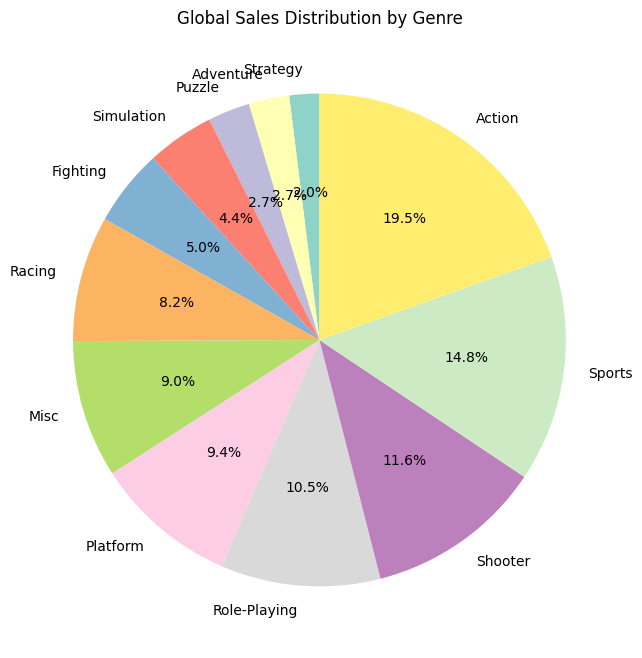

In [19]:
#pie chart

plt.figure(figsize=(8,8))

plt.pie(
    df_genre["global_sales"],
    labels=df_genre["genre"],
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Set3.colors
)

plt.title("Global Sales Distribution by Genre")
plt.show()

To answer this business question I have grouped all the records by their genre and aggregate the total sales for each one. Then I presented it on a pie chart the shows how Action and Sports games alone cover 1/3 of the entire market.

**Which platforms generated the highest sales?**

In [20]:
platform_sales = df.groupby('platform').agg({'eu_sales': 'sum', 'na_sales': 'sum', 'jp_sales': 'sum', 'other_sales': 'sum','global_sales':'sum'}).sort_values('global_sales', ascending = False).reset_index()[:10]
platform_sales

,platform,eu_sales,na_sales,jp_sales,other_sales,global_sales
0,PS2,332.63,572.92,137.54,190.47,1233.46
1,X360,278.01,594.33,12.30,84.67,969.61
2,PS3,340.47,388.90,79.21,140.81,949.35
3,Wii,264.35,497.37,68.28,79.20,909.81
4,DS,194.07,388.56,175.02,60.29,818.96
5,PS,212.38,334.71,139.78,40.69,727.39
6,GBA,74.59,184.12,46.56,7.61,313.56
7,PSP,67.16,107.09,75.89,41.52,291.71
8,PS4,123.70,96.80,14.30,43.36,278.10
9,PC,137.64,92.10,0.17,24.33,255.05


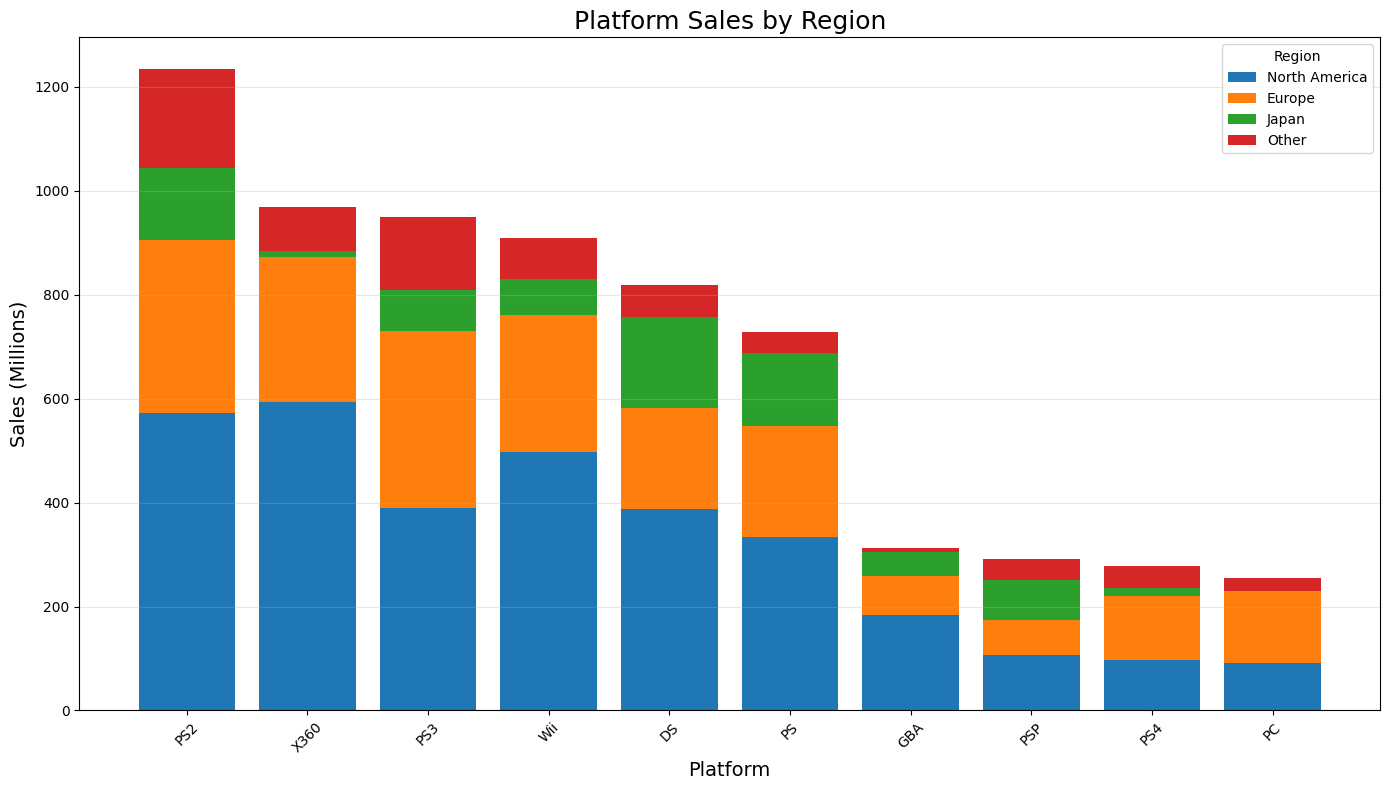

In [21]:
plt.figure(figsize=(14,8))

plt.bar(platform_sales["platform"], platform_sales["na_sales"], label="North America")

plt.bar(
    platform_sales["platform"],
    platform_sales["eu_sales"],
    bottom=platform_sales["na_sales"],
    label="Europe"
)

plt.bar(
    platform_sales["platform"],
    platform_sales["jp_sales"],
    bottom=platform_sales["na_sales"] + platform_sales["eu_sales"],
    label="Japan"
)

plt.bar(
    platform_sales["platform"],
    platform_sales["other_sales"],
    bottom=(
        platform_sales["na_sales"]
        + platform_sales["eu_sales"]
        + platform_sales["jp_sales"]
    ),
    label="Other"
)

plt.title("Platform Sales by Region", fontsize=18)
plt.xlabel("Platform", fontsize=14)
plt.ylabel("Sales (Millions)", fontsize=14)

plt.xticks(rotation=45)
plt.legend(title="Region")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
platform_first_year = df.groupby('platform')['year'].min().sort_values().reset_index()
platform_first_year

,platform,year
0,2600,1980
1,NES,1983
2,PC,1985
3,DS,1985
4,GB,1988
5,GEN,1990
6,SNES,1990
7,GG,1992
8,SCD,1993
9,NG,1993


In this analysis, similar to the top selling titles, I have grouped by console name and aggregated by the total sales, then visualizing it on a bar chart. The top selling console is the Ps2, even if is not the most selled in the North-American market, that is Xbox360. This is due to the Japanese market's rejection of Microsoft's product. To read correctly this chart I also printed the first time that each console appeared on the market for the first time (accordingly to this dataset). 

**How have global sales changed over time?**

In [23]:
#build a dataset grouping by year and aggregating the global sales

df_sales = df.groupby('year').agg({'eu_sales': 'sum', 'na_sales': 'sum', 'jp_sales': 'sum', 'other_sales': 'sum','global_sales':'sum'}).sort_values('year', ascending = True).reset_index()
df_sales

,year,eu_sales,na_sales,jp_sales,other_sales,global_sales
0,1980,0.67,10.59,0.00,0.12,11.38
1,1981,1.96,33.40,0.00,0.32,35.77
2,1982,1.65,26.92,0.00,0.31,28.86
3,1983,0.80,7.76,8.10,0.14,16.79
4,1984,2.10,33.28,14.27,0.70,50.36
5,1985,4.74,33.73,14.56,0.92,53.94
6,1986,2.84,12.50,19.81,1.93,37.07
7,1987,1.41,8.46,11.63,0.20,21.74
8,1988,6.59,23.87,15.76,0.99,47.22
9,1989,8.44,45.15,18.36,1.50,73.45


In [24]:
#top 5 year with most sales

df_sales.sort_values("global_sales", ascending=False).head(10)

#jp sales anticipated the trend

,year,eu_sales,na_sales,jp_sales,other_sales,global_sales
28,2008,184.40,351.44,60.26,82.39,678.90
29,2009,191.59,338.85,61.89,74.77,667.30
27,2007,160.50,312.05,60.29,77.60,611.13
30,2010,176.73,304.24,59.49,59.90,600.45
26,2006,129.24,263.12,73.73,54.43,521.04
31,2011,167.44,241.06,53.04,54.39,515.99
25,2005,121.94,242.61,54.28,40.58,459.94
24,2004,107.32,222.59,41.65,47.29,419.31
22,2002,109.74,216.19,41.76,27.28,395.52
33,2013,125.80,154.77,47.59,39.82,368.11


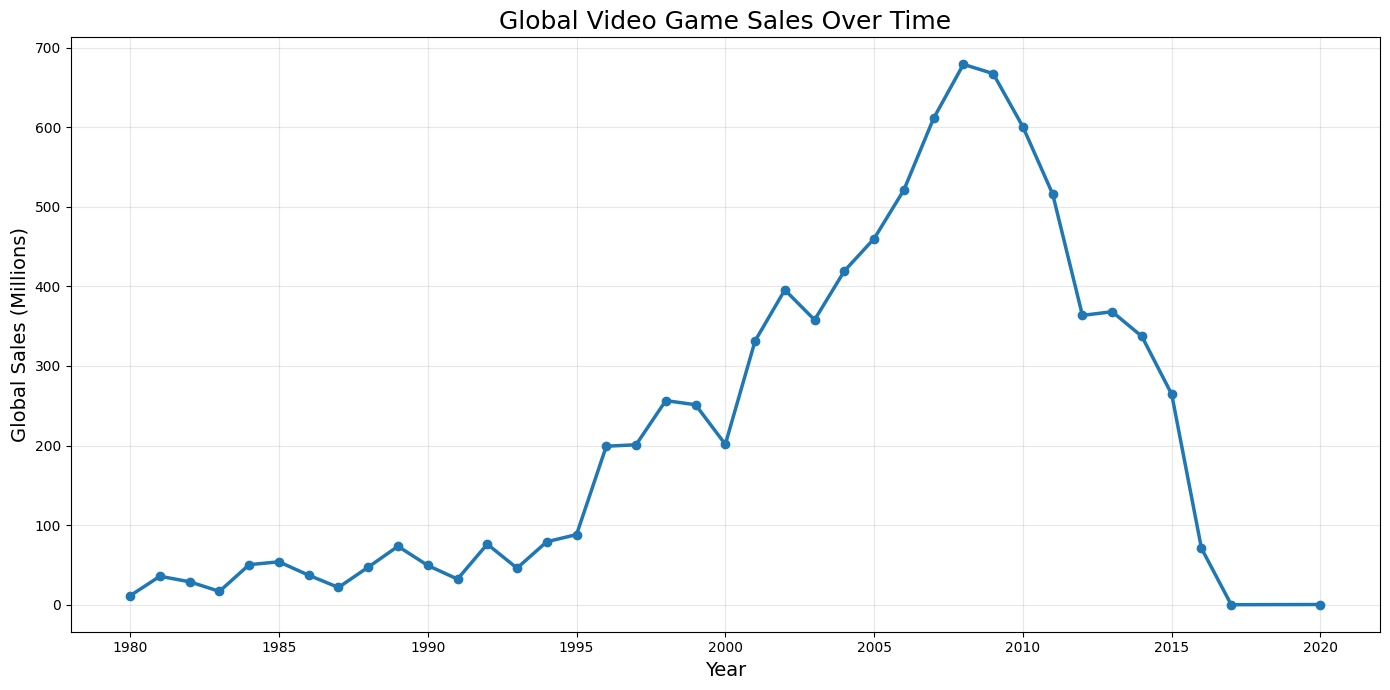

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,7))

plt.plot(
    df_sales["year"],
    df_sales["global_sales"],
    marker="o",
    linewidth=2.5
)

plt.title("Global Video Game Sales Over Time", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Global Sales (Millions)", fontsize=14)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

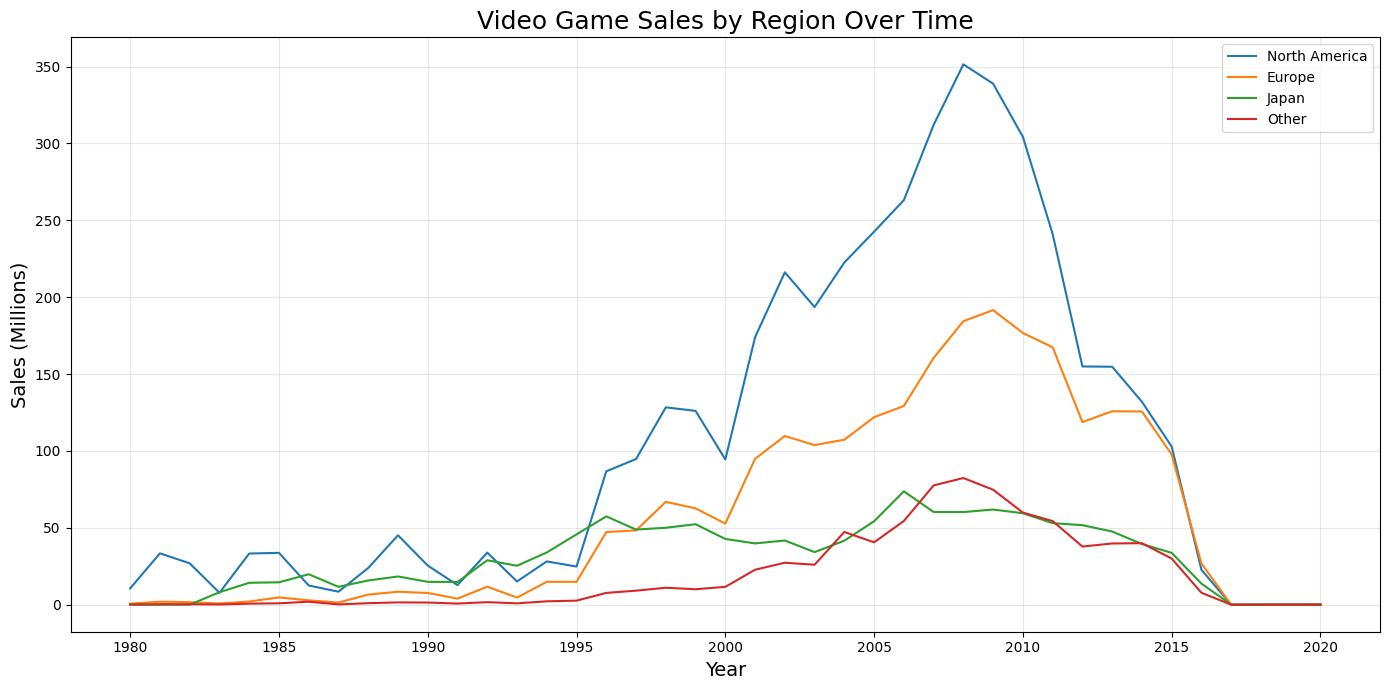

In [26]:
plt.figure(figsize=(14,7))

plt.plot(df_sales["year"], df_sales["na_sales"], label="North America")
plt.plot(df_sales["year"], df_sales["eu_sales"], label="Europe")
plt.plot(df_sales["year"], df_sales["jp_sales"], label="Japan")
plt.plot(df_sales["year"], df_sales["other_sales"], label="Other")

plt.title("Video Game Sales by Region Over Time", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Sales (Millions)", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
top_publishers = (df.groupby("publisher")["global_sales"].sum().nlargest(5).index)

In [28]:
publisher_trend = (df[df["publisher"].isin(top_publishers)].groupby(["year", "publisher"])["global_sales"].sum().reset_index())

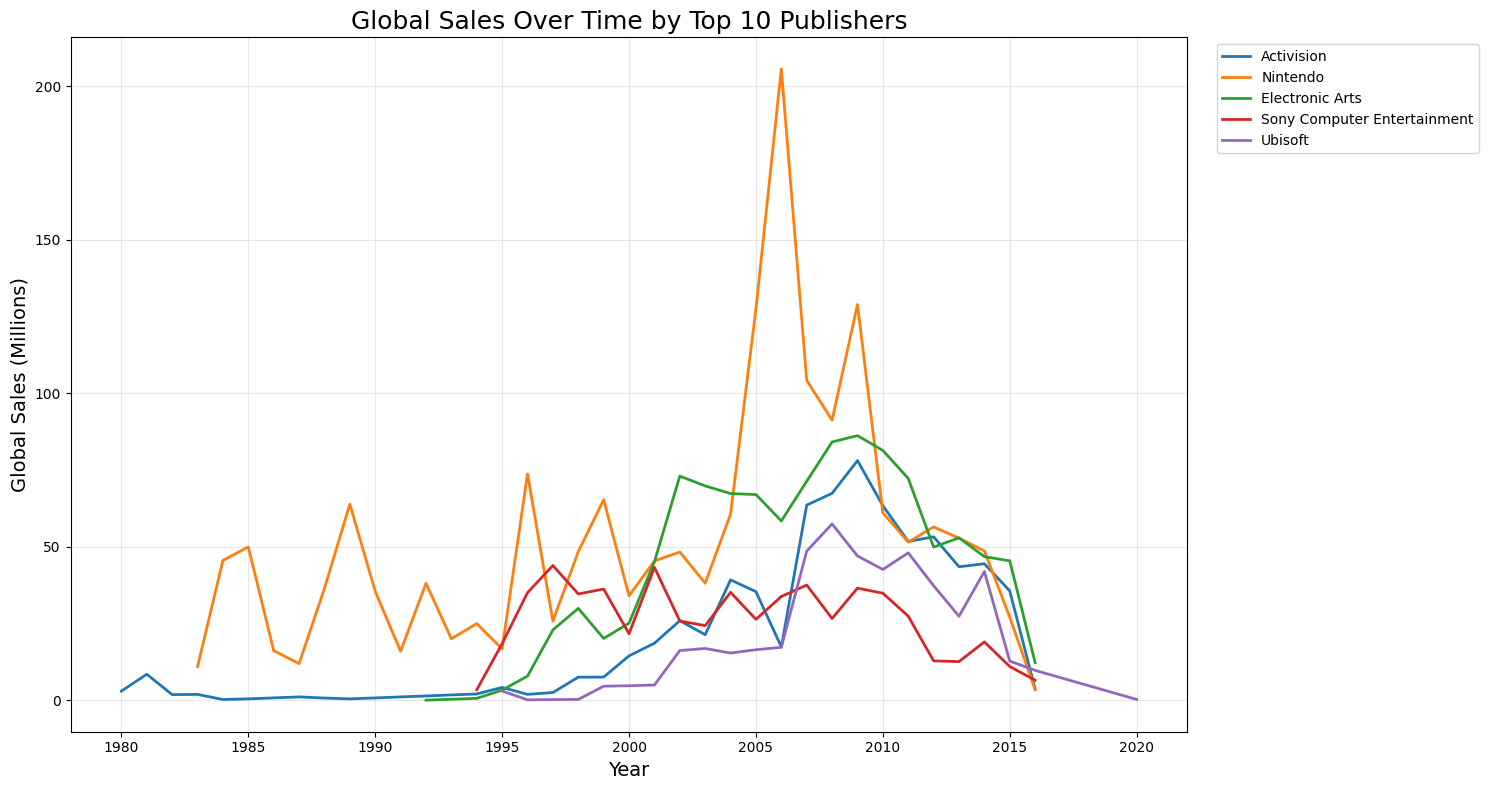

In [29]:
plt.figure(figsize=(15,8))

for publisher in publisher_trend["publisher"].unique():

    publisher_data = publisher_trend[
        publisher_trend["publisher"] == publisher
    ]

    plt.plot(
        publisher_data["year"],
        publisher_data["global_sales"],
        linewidth=2,
        label=publisher
    )

plt.title("Global Sales Over Time by Top 10 Publishers", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Global Sales (Millions)", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

For the last task I wanted to investigate the evolution of the video game market over time. First thing I grouped by year and aggregate the sales, then visualized it on a line chart to see the sales (on the y axis) over years (on the x axis). From this graph is possible to see the rising of the market during the 90's and the fast growing sales until late 2000's, then there is the sales collapse from 2010. The release of the PS2 and Xbox (the two top-selling consoles) in years 2000 and 2005 certainly contributed to the fast-rising sales. By grouping the top five years for sales, it's possible to see how the sales eak was anticipated by the Japanese market in 2006, looking at the line graph for regional sales over the years we can say that the japanese market, however small compared to the another anticipated growth trends and had a much more controlled decline.
From this brief analysis we can start to ask ourselves various questions that may go beyond the available dataset. Is the collapse due to the release of subscription-based streaming games? Are new consoles destined to sell less than their predecessors? How have smartphones and social networks affected this market?